In [1]:
#Hyperparameters

# Data
DATASET_NAME = "Kwaai/IMDB_Sentiment"
VALID_RATIO = 0.20

# Vocabulary
VOCAB_SIZE = 8_000
DROP_TOP_N = 50
PROTECTED_TOKENS = {
    "not", "no", "never", "neither", "nor",
    "but", "however", "although", "though", "yet",
    "good", "bad", "great", "best", "worst",
    "like", "love", "hate", "enjoy",
    "very", "really", "too", "so", "just",
    "more", "most", "less", "least",
    "hardly", "barely", "scarcely",
}
# Embedding model
EMBED_DIM = 50
EMBED_INIT_STD = 0.02

# Optimisation
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 1e-3
BATCH_SIZE = 256
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-5
SENTIMENT_WEIGHT = 1.0
GRAD_CLIP = 5.0

# Reproducibility and output
SEED = 42
DEVICE = "auto"
NUM_WORKERS=8

In [2]:
#import
import html
import random
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_device(name):
    if name != "auto":
        return torch.device(name)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


set_seed(SEED)
device = resolve_device(DEVICE)

print("Device:", device)

c:\Users\lulu\anaconda3\envs\yolo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [3]:
#get_data
raw_dataset = load_dataset(
    DATASET_NAME,
    download_mode="force_redownload",
)

labelled_split = raw_dataset["train"].train_test_split(
    test_size=VALID_RATIO,
    seed=SEED,
    stratify_by_column="label",
)

train_dataset = labelled_split["train"]
valid_dataset = labelled_split["test"]
unlabelled_dataset = raw_dataset["unsupervised"]
test_dataset = raw_dataset["test"]

Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 595208.59 examples/s]


In [4]:
BREAK_PATTERN = re.compile(r"<br\s*/?>", flags=re.IGNORECASE)
TOKEN_PATTERN = re.compile(
    r"[a-z]+(?:'[a-z]+)?|[!?]+|[:;=8xX][\-^']?[)(/\\dDpP]"
)


def tokenise(text):
    text = html.unescape(text)
    text = BREAK_PATTERN.sub(" ", text)
    return TOKEN_PATTERN.findall(text.lower())

In [5]:
token_counts = Counter()

for text in tqdm(
    train_dataset["text"],
    desc=f"Building vocabulary from {len(train_dataset):,} train reviews",
):
    token_counts.update(tokenise(text))

ranked_tokens = token_counts.most_common()


def is_protected_token(token):
    return (
        token in PROTECTED_TOKENS
        or token.endswith("n't")
        or re.fullmatch(r"[!?]+", token) is not None
    )


ignored_tokens = [
    token
    for token, _ in ranked_tokens
    if not is_protected_token(token)
][:DROP_TOP_N]
ignored_token_set = set(ignored_tokens)

vocabulary_tokens = [
    token
    for token, _ in ranked_tokens
    if token not in ignored_token_set
][:VOCAB_SIZE]

if len(vocabulary_tokens) < VOCAB_SIZE:
    raise ValueError("The training corpus contains fewer tokens than VOCAB_SIZE.")

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_ID = 0
UNK_ID = 1

id_to_token = [PAD_TOKEN, UNK_TOKEN] + vocabulary_tokens
token_to_id = {
    token: token_id
    for token_id, token in enumerate(id_to_token)
}
TOTAL_VOCAB_SIZE = len(id_to_token)

print("Ignored top-frequency tokens:", ignored_tokens[:50])
print("Embedding matrix rows:", TOTAL_VOCAB_SIZE)

Building vocabulary from 20,000 train reviews: 100%|██████████| 20000/20000 [00:02<00:00, 9437.78it/s]

Ignored top-frequency tokens: ['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'film', 'on', 'you', 'his', 'are', 'have', 'he', 'be', 'one', 'all', 'at', 'by', 'an', 'they', 'who', 'from', 'her', 'or', 'about', "it's", 'out', 'if', 'has', 'there', 'some', 'what', 'when', 'up', 'even', 'time', 'she', 'my', 'would', 'which']
Embedding matrix rows: 8002


In [10]:
# ============================================================
# 1. Confirm the correct split
# ============================================================

print(
    "train =", len(train_dataset),
    "| validation =", len(valid_dataset),
    "| test =", len(test_dataset)
)

assert len(train_dataset) == 20_000
assert len(valid_dataset) == 5_000
assert len(test_dataset) == 25_000


# ============================================================
# 2. Count tokens
# ============================================================

def count_tokens(dataset):
    counts = Counter()

    for text in dataset["text"]:
        counts.update(tokenise(text))

    return counts


train_counts = count_tokens(train_dataset)
val_counts = count_tokens(valid_dataset)


# Reproduce the protected-token rule
def is_protected(token):
    punctuation_signal = (
        len(token) > 0
        and set(token).issubset({"!", "?"})
    )

    return (
        token in PROTECTED_TOKENS
        or token.endswith("n't")
        or punctuation_signal
    )


# Remove the 50 most frequent non-protected tokens
non_protected_tokens = [
    token
    for token, _ in train_counts.most_common()
    if not is_protected(token)
]

removed_tokens = set(
    non_protected_tokens[:DROP_TOP_N]
)


# Remaining tokens ranked by training frequency
ranked_tokens = [
    token
    for token, _ in train_counts.most_common()
    if token not in removed_tokens
]


# ============================================================
# 3. Compare vocabulary sizes
# ============================================================

def calculate_coverage(counts, vocabulary):
    total_occurrences = sum(counts.values())

    # Exclude the deliberately removed top-50 words
    eligible_occurrences = sum(
        count
        for token, count in counts.items()
        if token not in removed_tokens
    )

    retained_occurrences = sum(
        counts.get(token, 0)
        for token in vocabulary
    )

    raw_coverage = (
        retained_occurrences / total_occurrences
    )

    eligible_coverage = (
        retained_occurrences / eligible_occurrences
    )

    return raw_coverage, eligible_coverage


vocabulary_sizes = [
    2_000,
    4_000,
    6_000,
    8_000,
    10_000,
    12_000,
    14_000,
    16_000,
    18_000,
    20_000
]

rows = []

for vocabulary_size in vocabulary_sizes:

    vocabulary = set(
        ranked_tokens[:vocabulary_size]
    )

    train_raw, train_eligible = calculate_coverage(
        train_counts,
        vocabulary
    )

    val_raw, val_eligible = calculate_coverage(
        val_counts,
        vocabulary
    )

    cutoff_frequency = train_counts[
        ranked_tokens[vocabulary_size - 1]
    ]

    embedding_parameters = (
        vocabulary_size + 2
    ) * EMBED_DIM

    rows.append({
        "vocabulary_size": vocabulary_size,
        "cutoff_frequency": cutoff_frequency,
        "train_eligible_coverage": train_eligible,
        "validation_eligible_coverage": val_eligible,
        "validation_raw_coverage": val_raw,
        "embedding_parameters": embedding_parameters
    })


coverage_df = pd.DataFrame(rows)

coverage_df["marginal_validation_gain"] = (
    coverage_df["validation_eligible_coverage"]
    .diff()
)

display(
    coverage_df.style.format({
        "train_eligible_coverage": "{:.2%}",
        "validation_eligible_coverage": "{:.2%}",
        "validation_raw_coverage": "{:.2%}",
        "marginal_validation_gain": "{:.2%}"
    })
)

train = 20000 | validation = 5000 | test = 25000


,vocabulary_size,cutoff_frequency,train_eligible_coverage,validation_eligible_coverage,validation_raw_coverage,embedding_parameters,marginal_validation_gain
0,2000,201,71.82%,71.55%,42.58%,100100,nan%
1,4000,85,81.16%,80.79%,48.08%,200100,9.24%
2,6000,50,85.86%,85.46%,50.86%,300100,4.67%
3,8000,33,88.81%,88.37%,52.59%,400100,2.91%
4,10000,24,90.85%,90.34%,53.76%,500100,1.97%
5,12000,18,92.36%,91.80%,54.63%,600100,1.46%
6,14000,14,93.52%,92.91%,55.29%,700100,1.12%
7,16000,11,94.44%,93.81%,55.83%,800100,0.90%
8,18000,9,95.18%,94.54%,56.26%,900100,0.72%
9,20000,8,95.80%,95.15%,56.62%,1000100,0.61%


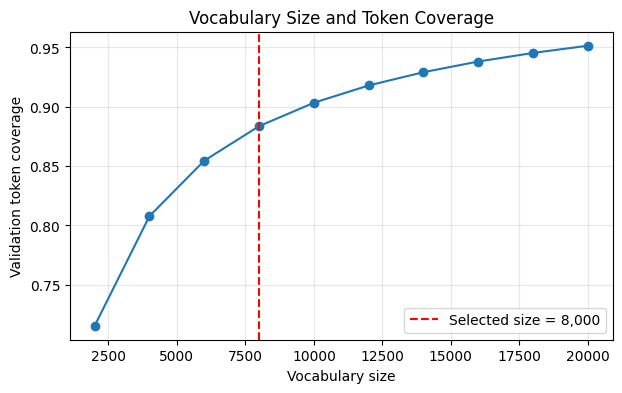

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))

plt.plot(
    coverage_df["vocabulary_size"],
    coverage_df["validation_eligible_coverage"],
    marker="o"
)

plt.axvline(
    8_000,
    color="red",
    linestyle="--",
    label="Selected size = 8,000"
)

plt.xlabel("Vocabulary size")
plt.ylabel("Validation token coverage")
plt.title("Vocabulary Size and Token Coverage")
plt.legend()
plt.grid(alpha=0.3)
plt.show()